<a href="https://colab.research.google.com/github/sbracco2003/DiabetesRisk/blob/main/Notebook/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting 30-Day Hospital Readmissions with Machine Learning

This notebook develops and interprets machine learning models to predict whether a diabetic patient will be readmitted within 30 days of discharge using the Diabetes 130-US hospitals dataset.

**Notebook roadmap**
1. Data loading and initial assessment  
2. Cleaning and preprocessing  
3. Baseline model: Logistic Regression  
4. Final model: Calibrated XGBoost  
5. Interpretation with SHAP and scenario analysis  
6. Business evaluation, fairness checks, and risk targeting  


## 1. Imports and Setup

In [58]:
import sklearn
import pandas as pd
import numpy as np

## 2. Load Data

Load the diabetes readmission dataset from Google Drive.

In [59]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Projects/Diabetes/diabetic_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [61]:
len(df)

101766

## 3. Initial Data Assessment

Check a few high-level properties of the dataset before cleaning.

In [62]:
(df['weight']).value_counts(normalize=True) #check percent of weight values missing


,proportion
weight,
?,0.968585
[75-100),0.013128
[50-75),0.008814
[100-125),0.006142
[125-150),0.001425
[25-50),0.000953
[0-25),0.000472
[150-175),0.000344
[175-200),0.000108


In [63]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [64]:
#Find average and max for num_lab_procedures and num_procedures
print("labs mean:", df['num_lab_procedures'].mean())
print("procedures:", df['num_procedures'].mean())
print(df['num_lab_procedures'].max())
print(df['num_procedures'].max())

labs mean: 43.09564098028811
procedures: 1.339730361810428
132
6


## 4. Data Cleaning

Key cleaning decisions:
- strip whitespace from column names
- drop `weight` because it is overwhelmingly missing
- convert `"?"` placeholders to proper missing values
- replace coded admission/discharge IDs with semantic labels where useful


In [65]:
df.columns = df.columns.str.strip() #strip just in case there is white space in text


In [66]:
df.drop(columns=['weight'], inplace=True) #inplace keeps the same dataframe


In [67]:
#drop rows where race is ?
df = df.replace('?', np.nan)          # standard missing
df = df.replace({pd.NA: np.nan})      # just in case any pd.NA remains
df = df.dropna(subset=['race'])

In [68]:
#check number of admission types
df['admission_type_id'].value_counts()

,count
admission_type_id,
1,52900
3,18508
2,17786
6,5225
5,4727
8,317
7,20
4,10


In [69]:
#Load IDs
ids_df = pd.read_csv('/content/drive/MyDrive/Projects/Diabetes/IDS_mapping.csv')

In [70]:
ids_df.head(67)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


In [71]:
###Replace number ids with semantic text
admission_map = ids_df[['admission_type_id', 'description']].dropna(subset=['admission_type_id']).copy()
admission_map = admission_map.drop_duplicates(subset=['admission_type_id'])
#set to same dtype
df['admission_type_id'] = pd.to_numeric(df['admission_type_id'], errors='coerce')
admission_map['admission_type_id'] = pd.to_numeric(admission_map['admission_type_id'], errors='coerce')

#merge
df = df.merge(admission_map, on='admission_type_id', how='left')

#drop original
df.drop(columns = ['admission_type_id'], inplace = True)

In [72]:
df.rename(columns={'description': 'Admission_Type'}, inplace=True)
df

,encounter_id,patient_nbr,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Admission_Type
0,2278392,8222157,Caucasian,Female,[0-10),25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,NO,NaN
1,149190,55629189,Caucasian,Female,[10-20),1,7,3,NaN,NaN,...,Up,No,No,No,No,No,Ch,Yes,>30,Emergency
2,64410,86047875,AfricanAmerican,Female,[20-30),1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,Yes,NO,Emergency
3,500364,82442376,Caucasian,Male,[30-40),1,7,2,NaN,NaN,...,Up,No,No,No,No,No,Ch,Yes,NO,Emergency
4,16680,42519267,Caucasian,Male,[40-50),1,7,1,NaN,NaN,...,Steady,No,No,No,No,No,Ch,Yes,NO,Emergency
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99488,443847548,100162476,AfricanAmerican,Male,[70-80),3,7,3,MC,NaN,...,Down,No,No,No,No,No,Ch,Yes,>30,Emergency
99489,443847782,74694222,AfricanAmerican,Female,[80-90),4,5,5,MC,NaN,...,Steady,No,No,No,No,No,No,Yes,NO,Emergency
99490,443854148,41088789,Caucasian,Male,[70-80),1,7,1,MC,NaN,...,Down,No,No,No,No,No,Ch,Yes,NO,Emergency
99491,443857166,31693671,Caucasian,Female,[80-90),3,7,10,MC,Surgery-General,...,Up,No,No,No,No,No,Ch,Yes,NO,Urgent


In [73]:
df['Admission_Type'].value_counts()

,count
Admission_Type,
Emergency,52900
Elective,18508
Urgent,17786
Not Available,4727
Not Mapped,317
Trauma Center,20
Newborn,10


In [74]:
#Check Discharge types
df['discharge_disposition_id'].value_counts()

,count
discharge_disposition_id,
1,58768
3,13614
6,12698
18,3673
2,2061
22,1981
11,1608
5,1143
25,973


## 5. Define Prediction Target

Use the standard binary framing: predict whether a patient is readmitted **within 30 days** (`<30`) versus all other outcomes.

In [75]:
#Check for missing values in readmitted
df['readmitted'].value_counts()

,count
readmitted,
NO,53317
>30,35007
<30,11169


In [76]:
#Set variables. y will be patients who were readmitted within 30 days (standard clinical practice)
y = (df['readmitted'] == '<30').astype(int)
y.value_counts(normalize=True)

,proportion
readmitted,
0,0.887741
1,0.112259


In [77]:
#Drop irrelevant columns from X because we only want it to base predictions off of its own features
X = df.drop(columns= ['readmitted','encounter_id','patient_nbr'], errors = 'ignore')
X.head()

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,Admission_Type
0,Caucasian,Female,[0-10),25,1,1,NaN,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,NaN
1,Caucasian,Female,[10-20),1,7,3,NaN,NaN,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,Emergency
2,AfricanAmerican,Female,[20-30),1,7,2,NaN,NaN,11,5,...,No,No,No,No,No,No,No,No,Yes,Emergency
3,Caucasian,Male,[30-40),1,7,2,NaN,NaN,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,Emergency
4,Caucasian,Male,[40-50),1,7,1,NaN,NaN,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,Emergency


In [78]:
#Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

## 6. Preprocessing Pipeline

Create a reusable preprocessing pipeline that imputes missing values, scales numeric features for logistic regression, and one-hot encodes categorical variables.

In [79]:
#Imports
from sklearn.compose import ColumnTransformer #allows preprocessing for both types of columns we have, numerical and categorical
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler #sort text labels and scale data proportionately
from sklearn.impute import SimpleImputer #fill in na/missing values
from sklearn.linear_model import LogisticRegression

cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])


## 7. Baseline Model: Logistic Regression

In [80]:
from sklearn.metrics import roc_auc_score, average_precision_score

clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]

print("Baseline ROC-AUC:", roc_auc_score(y_test, proba))
print("Baseline PR-AUC :", average_precision_score(y_test, proba))

Baseline ROC-AUC: 0.6399983934566553
Baseline PR-AUC : 0.20112006171880797


## 8. Threshold Selection for the Baseline Model

Rather than relying on the default 0.5 cutoff, inspect precision-recall tradeoffs and define a helper function to choose thresholds by target recall.

In [81]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba)

In [82]:
def threshold_for_recall(target_recall, precision, recall, thresholds):
    # ignore last recall point (which corresponds to predicting everything positive)
    valid = recall[:-1] >= target_recall

    if not valid.any():
        return None

    idx = np.where(valid)[0][-1]  # last index meeting recall target
    return precision[idx], recall[idx], thresholds[idx]

for r in [0.20, 0.30, 0.40]:
    result = threshold_for_recall(r, precision, recall, thresholds)
    print("Target recall:", r, result)

Target recall: 0.2 (np.float64(0.24805771365149834), np.float64(0.20008952551477172), np.float64(0.6725071278102789))
Target recall: 0.3 (np.float64(0.20857942182157288), np.float64(0.30035810205908686), np.float64(0.609160130732655))
Target recall: 0.4 (np.float64(0.1871859296482412), np.float64(0.40017905102954343), np.float64(0.5601252830905002))


## 9. Nonlinear Model: XGBoost

Train a gradient-boosted tree model on the same feature set to capture nonlinear interactions and compare it against the linear baseline.

In [83]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb)
])

xgb_pipe.fit(X_train, y_train);

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [84]:
from sklearn.metrics import roc_auc_score, average_precision_score

xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]

print("XGB ROC-AUC:", roc_auc_score(y_test, xgb_proba))
print("XGB PR-AUC :", average_precision_score(y_test, xgb_proba))

XGB ROC-AUC: 0.6761946385543542
XGB PR-AUC : 0.22763685983325255


## 10. Probability Calibration

Calibrate XGBoost probabilities so predicted risk can be interpreted as an actual estimated readmission probability.

In [85]:
from sklearn.calibration import CalibratedClassifierCV

# Take the fitted xgb_pipe's model definition (not fitted probabilities)
xgb_uncal = xgb_pipe  # your pipeline object

calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb_uncal,
    method="isotonic",   # try "sigmoid" if isotonic is slow
    cv=3                 # keep it smaller
)

calibrated_xgb.fit(X_train, y_train);

CalibratedClassifierCV(cv=3,
                       estimator=Pipeline(steps=[('preprocess',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   Index(['discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', '...
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=4,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=300,
                                                                n_jobs=-1,
                                                                num_parallel_tree=None, ...))]),
                       method='isotonic')

In [86]:
cal_proba_test = calibrated_xgb.predict_proba(X_test)[:, 1]
cal_proba_test.mean(), y_test.mean()

(np.float64(0.11130566713785271), np.float64(0.11226694808784361))

## 11. Global Model Interpretation with SHAP

Compute SHAP values to understand which features drive readmission risk globally.

In [87]:
!pip -q install shap
import shap

In [88]:
# fitted pieces from your pipeline
pre = xgb_pipe.named_steps["preprocess"]
xgb_model = xgb_pipe.named_steps["model"]

# feature names after one-hot
feature_names = pre.get_feature_names_out()

# transform train/test
X_train_t = pre.transform(X_train)
X_test_t  = pre.transform(X_test)

# Optional: if sparse, keep it sparse (good). For some plotting, dense is heavy.

In [89]:
# Random samples for background and explanation
rng = np.random.default_rng(42)

bg_idx = rng.choice(X_train_t.shape[0], size=min(200, X_train_t.shape[0]), replace=False)
ex_idx = rng.choice(X_test_t.shape[0], size=min(500, X_test_t.shape[0]), replace=False)

# Convert sparse → dense
X_bg = X_train_t[bg_idx].toarray()
X_ex = X_test_t[ex_idx].toarray()

# Build explainer
explainer = shap.TreeExplainer(xgb_model, data=X_bg)

# Compute SHAP values
shap_vals = explainer.shap_values(X_ex)

# Binary models sometimes return list
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

In [90]:
clean_feature_names = (
    pd.Series(feature_names)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
    .values
)

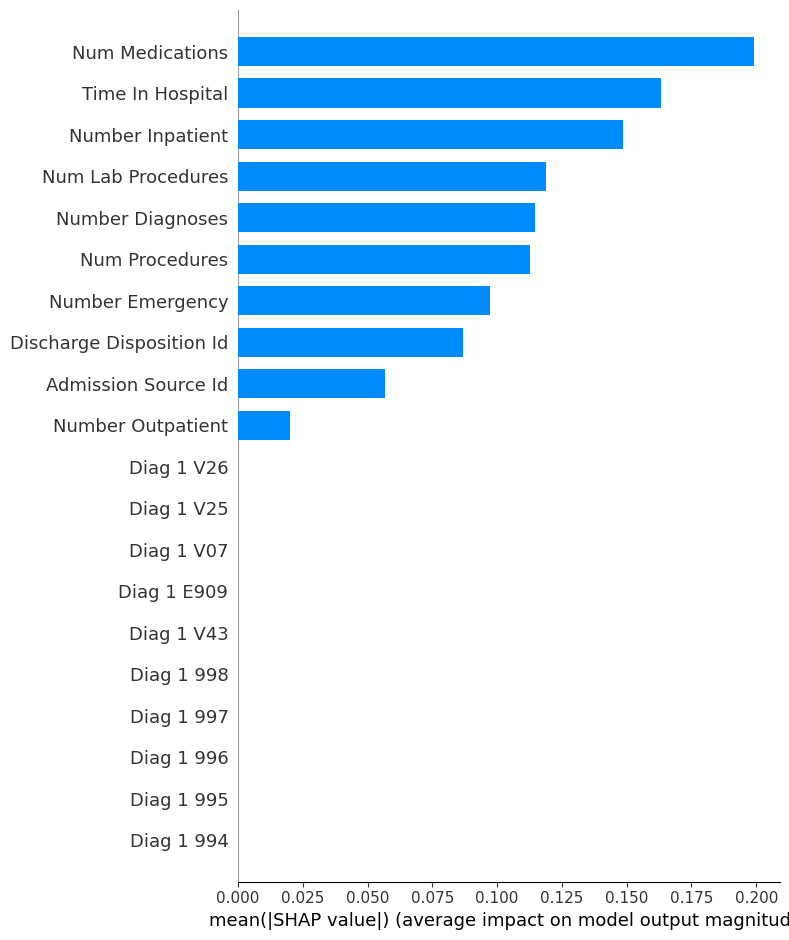

In [91]:
plt.figure(figsize=(16, 10))
shap.summary_plot(
    shap_vals,
    X_ex,
    feature_names=clean_feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.tight_layout()
plt.show()

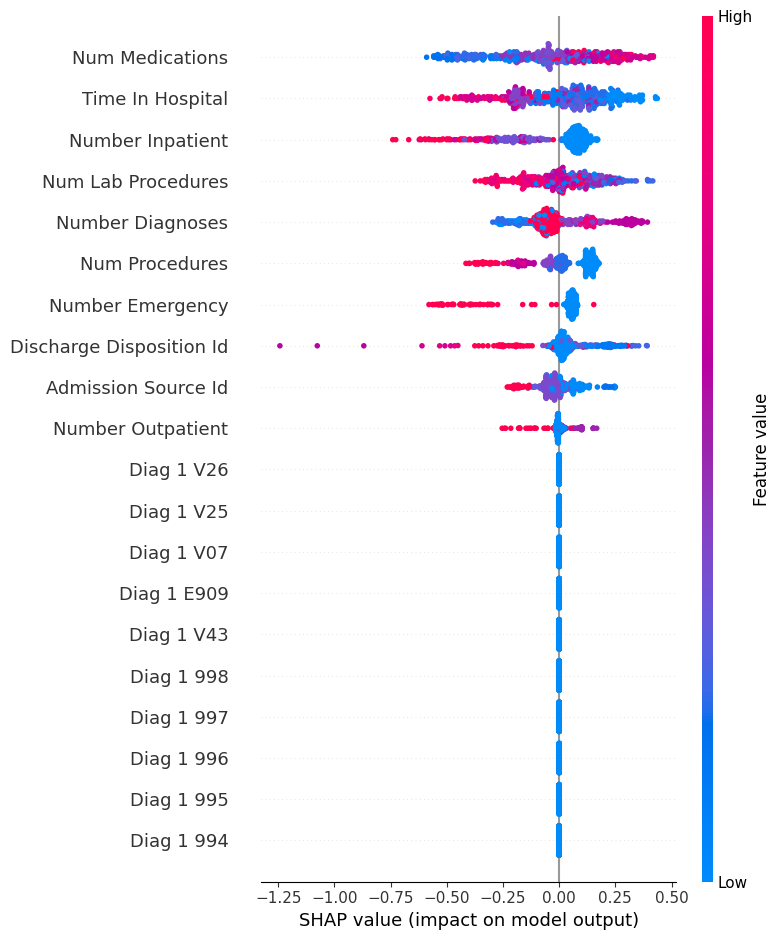

In [92]:
plt.figure(figsize=(16, 10))
shap.summary_plot(
    shap_vals,
    X_ex,
    feature_names=clean_feature_names,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.show()

## 12. Scenario Analysis: Low-Risk vs High-Risk Patient Profiles

Construct example patient profiles and compare calibrated probabilities to show how risk changes across clinically meaningful scenarios.

In [93]:
X_train.describe()

,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,79594.000000,79594.000000,79594.000000,79594.000000,79594.000000,79594.000000,79594.000000,79594.000000,79594.000000,79594.000000
mean,3.740181,5.773940,4.403422,43.032100,1.340001,16.025655,0.373269,0.202163,0.644697,7.444795
std,5.313215,4.080435,2.986356,19.716806,1.702176,8.090378,1.287209,0.890186,1.273213,1.922316
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,63.000000,21.000000,16.000000


In [94]:
#baseline patient using mode
X_train.mode().iloc[0]

,0
race,Caucasian
gender,Female
age,[70-80)
discharge_disposition_id,1
admission_source_id,7
time_in_hospital,3
payer_code,MC
medical_specialty,InternalMedicine
num_lab_procedures,1
num_procedures,0


In [103]:
#building low-risk patient
low_risk = baseline.copy()
low_risk = low_risk.to_frame().T

low_risk["age"] = "[40-50)"
low_risk["Admission_Type"] = "Elective"
low_risk["number_inpatient"] = 0
low_risk["number_emergency"] = 0
low_risk["num_medications"] = 1
low_risk["time_in_hospital"] = 1
low_risk["number_diagnoses"] = 1
low_risk["A1Cresult"] = "Norm"

pandas.core.frame.DataFrame

In [105]:
true_low = low_risk.copy()

true_low["age"] = "[30-40)"
true_low["Admission_Type"] = "Elective"
true_low["diag_1"] = "530"  # non-severe GI issue
true_low["diag_2"] = "0"
true_low["diag_3"] = "0"
true_low["A1Cresult"] = "Norm"
true_low["diabetesMed"] = "No"
true_low["num_medications"] = 5
true_low["time_in_hospital"] = 2
true_low["number_diagnoses"] = 3
true_low["number_inpatient"] = 0
true_low["number_emergency"] = 0

pandas.core.frame.DataFrame

In [106]:
calibrated_xgb.predict_proba(true_low)[:, 1]


array([0.03721093])

In [107]:
high_risk = true_low.copy()

# Demographics
high_risk["age"] = "[70-80)"
high_risk["Admission_Type"] = "Emergency"

# Utilization burden
high_risk["time_in_hospital"] = 9
high_risk["num_medications"] = 28
high_risk["number_inpatient"] = 3
high_risk["number_emergency"] = 2
high_risk["number_outpatient"] = 2

# Clinical burden
high_risk["number_diagnoses"] = 11
high_risk["num_lab_procedures"] = 65
high_risk["num_procedures"] = 3

# Diagnoses (heart failure + diabetes)
high_risk["diag_1"] = "428"   # heart failure
high_risk["diag_2"] = "250"   # diabetes
high_risk["diag_3"] = "276"   # electrolyte disorder

# Diabetes indicators
high_risk["A1Cresult"] = ">8"
high_risk["diabetesMed"] = "Yes"

In [108]:
calibrated_xgb.predict_proba(high_risk)[:,1]

array([0.20789809])

In [109]:
#LOG ODDS
import numpy as np

def logit(p):
    # avoid infinities
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

p_low  = float(calibrated_xgb.predict_proba(true_low)[:, 1])
p_high = float(calibrated_xgb.predict_proba(high_risk)[:, 1])
p_base = float(y_test.mean())

print("Calibrated p(low) :", p_low)
print("Calibrated p(high):", p_high)
print("Base rate p       :", p_base)

print("\nLog-odds (low) :", logit(p_low))
print("Log-odds (high):", logit(p_high))
print("Log-odds (base):", logit(p_base))

print("\nΔ log-odds (high - low):", logit(p_high) - logit(p_low))
print("Odds ratio (high vs low):", np.exp(logit(p_high) - logit(p_low)))

Calibrated p(low) : 0.03721092827618122
Calibrated p(high): 0.20789809028307596
Base rate p       : 0.11226694808784361

Log-odds (low) : -3.2532318663271713
Log-odds (high): -1.3376420483474691
Log-odds (base): -2.0677915801640996

Δ log-odds (high - low): 1.9155898179797022
Odds ratio (high vs low): 6.790943036299003


/tmp/ipykernel_12384/17975196.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_low  = float(calibrated_xgb.predict_proba(true_low)[:, 1])
/tmp/ipykernel_12384/17975196.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_high = float(calibrated_xgb.predict_proba(high_risk)[:, 1])


## 13. Local Explanation: SHAP Dependence Plots

Inspect nonlinear relationships and interaction effects in the final model.

<Figure size 1000x600 with 0 Axes>

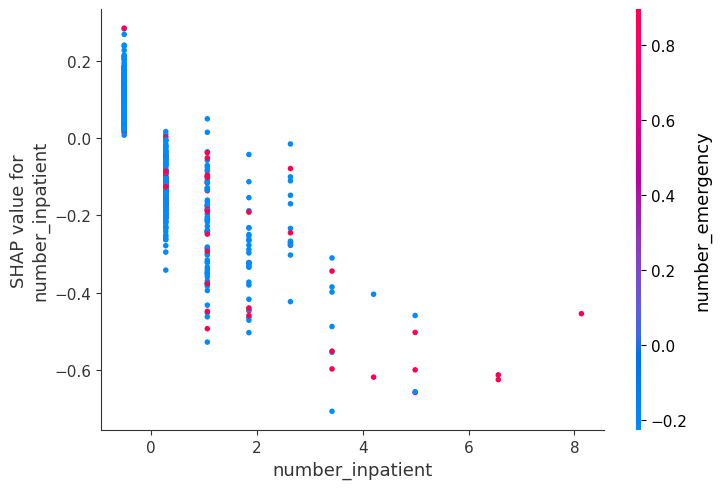

In [110]:
import shap


# fitted pipeline parts
pre = xgb_pipe.named_steps["preprocess"]
xgb_model = xgb_pipe.named_steps["model"]

# clean feature names
feature_names = pre.get_feature_names_out()
clean_feature_names = (
    pd.Series(feature_names)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .values
)

# transform a manageable sample
X_test_t = pre.transform(X_test)

rng = np.random.default_rng(42)
ex_idx = rng.choice(X_test_t.shape[0], size=min(1000, X_test_t.shape[0]), replace=False)

X_ex = X_test_t[ex_idx].toarray()

# SHAP values
explainer = shap.TreeExplainer(xgb_model, data=X_ex[:200])
shap_vals = explainer.shap_values(X_ex)

if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

# DataFrame for dependence plot
X_ex_df = pd.DataFrame(X_ex, columns=clean_feature_names)

# 1) Number Inpatient dependence, colored by Number Emergency
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "number_inpatient",
    shap_vals,
    X_ex_df,
    interaction_index="number_emergency",
    show=False
)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

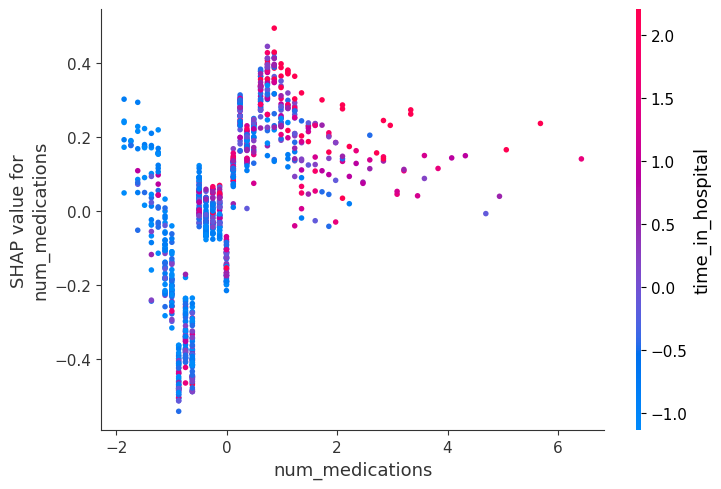

In [111]:
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "num_medications",
    shap_vals,
    X_ex_df,
    interaction_index="time_in_hospital",
    show=False
)
plt.tight_layout()
plt.show()

## 14. Risk Distribution and Partial Dependence

Visualize how predicted risk is distributed and how prior inpatient utilization affects predicted readmission probability.

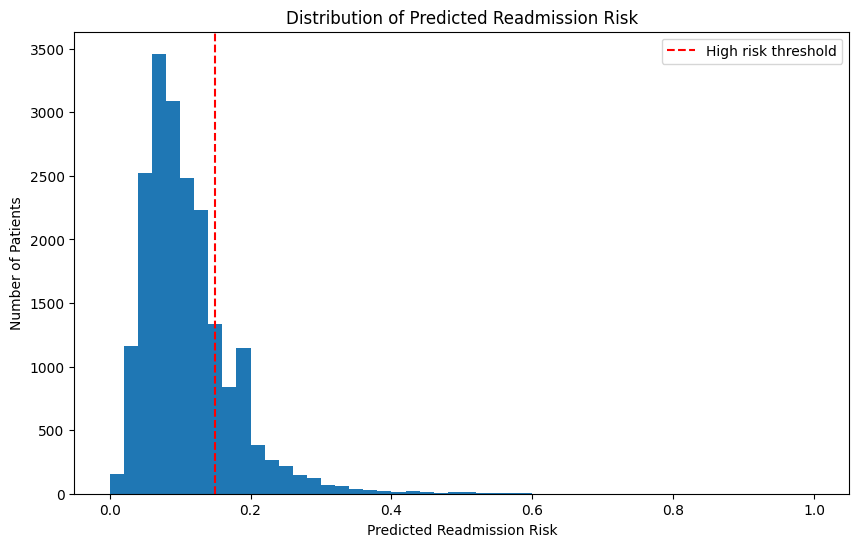

In [112]:
probs = calibrated_xgb.predict_proba(X_test)[:,1]

plt.figure(figsize=(10,6))
plt.hist(probs, bins=50)
plt.axvline(0.15, color="red", linestyle="--", label="High risk threshold")
plt.xlabel("Predicted Readmission Risk")
plt.ylabel("Number of Patients")
plt.title("Distribution of Predicted Readmission Risk")
plt.legend()
plt.show()

<Figure size 1000x600 with 0 Axes>

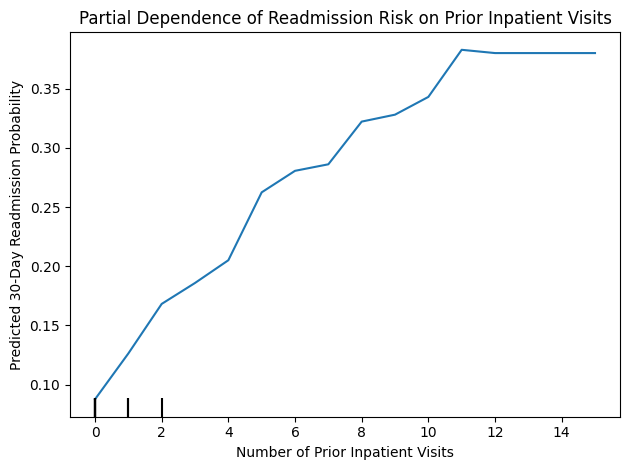

In [113]:
from sklearn.inspection import PartialDependenceDisplay

# calibrated model is better if you want interpretable probabilities
model_for_pdp = calibrated_xgb

plt.figure(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model_for_pdp,
    X_test,
    features=["number_inpatient"],
    kind="average"
)
plt.title("Partial Dependence of Readmission Risk on Prior Inpatient Visits")
plt.xlabel("Number of Prior Inpatient Visits")
plt.ylabel("Predicted 30-Day Readmission Probability")
plt.tight_layout()
plt.show()

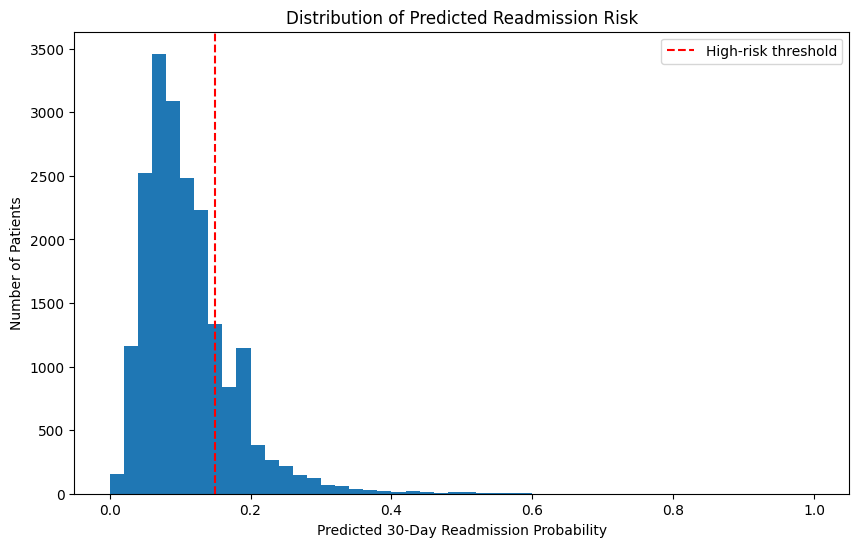

In [114]:
probs = calibrated_xgb.predict_proba(X_test)[:,1]

plt.figure(figsize=(10,6))
plt.hist(probs, bins=50)
plt.xlabel("Predicted 30-Day Readmission Probability")
plt.ylabel("Number of Patients")
plt.title("Distribution of Predicted Readmission Risk")

plt.axvline(0.15, color="red", linestyle="--", label="High-risk threshold")
plt.legend()
plt.show()

## 15. Fairness Checks

Compare average predicted risk across demographic groups.

In [115]:
X_test["pred_risk"] = probs

X_test.groupby("race")["pred_risk"].mean()

,pred_risk
race,
AfricanAmerican,0.113091
Asian,0.099527
Caucasian,0.111630
Hispanic,0.099925
Other,0.093037


In [116]:
X_test.groupby("gender")["pred_risk"].mean()

,pred_risk
gender,
Female,0.112176
Male,0.110290


In [117]:
X_test.groupby("age")["pred_risk"].mean()

,pred_risk
age,
[0-10),0.033688
[10-20),0.066929
[20-30),0.135246
[30-40),0.105182
[40-50),0.105660
[50-60),0.099987
[60-70),0.110638
[70-80),0.116350
[80-90),0.120240


In [118]:
high_risk_rate = (probs > 0.15).mean()
print(high_risk_rate)

0.2001608121011106


## 16. Lift, Gains, and Calibration Evaluation

Evaluate how well the model concentrates readmission risk among the highest-risk patients.

In [119]:
#Lift Chart
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build dataframe with predictions
df_lift = pd.DataFrame({
    "prob": probs,
    "actual": y_test
})

# Sort by predicted probability (highest risk first)
df_lift = df_lift.sort_values("prob", ascending=False).reset_index(drop=True)

# Create deciles
df_lift["decile"] = pd.qcut(df_lift.index, 10, labels=False)

# Aggregate
lift_table = df_lift.groupby("decile").agg(
    avg_pred_prob=("prob", "mean"),
    readmission_rate=("actual", "mean"),
    count=("actual", "count")
).sort_index()

# Baseline readmission rate
baseline_rate = df_lift["actual"].mean()

# Lift calculation
lift_table["lift"] = lift_table["readmission_rate"] / baseline_rate

print(lift_table)

        avg_pred_prob  readmission_rate  count      lift
decile                                                  
0            0.254096          0.263819   1990  2.349927
1            0.171215          0.177387   1990  1.580046
2            0.138569          0.144221   1990  1.284627
3            0.120856          0.118090   1990  1.051872
4            0.104475          0.100000   1990  0.890734
5            0.090658          0.086978   1989  0.774746
6            0.077601          0.077889   1990  0.693788
7            0.065713          0.062312   1990  0.555030
8            0.054403          0.052764   1990  0.469985
9            0.035459          0.039196   1990  0.349132


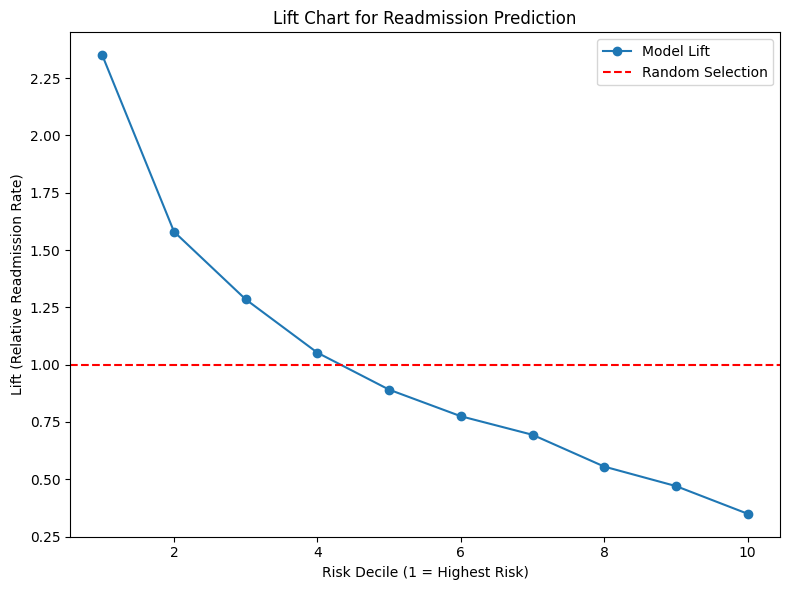

In [120]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    lift_table["lift"],
    marker="o",
    label="Model Lift"
)

plt.axhline(1, linestyle="--", color="red", label="Random Selection")

plt.xlabel("Risk Decile (1 = Highest Risk)")
plt.ylabel("Lift (Relative Readmission Rate)")
plt.title("Lift Chart for Readmission Prediction")
plt.legend()
plt.tight_layout()
plt.show()

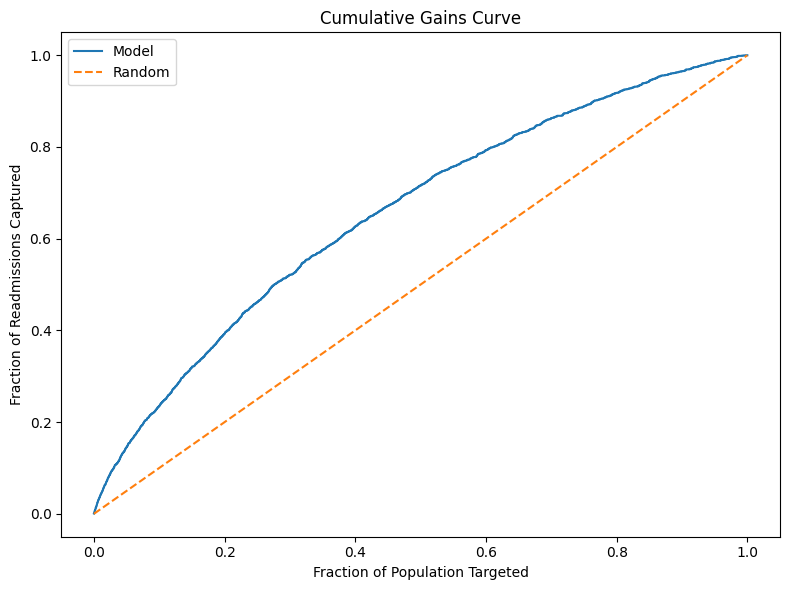

In [121]:
df_lift["cum_readmit"] = df_lift["actual"].cumsum()
df_lift["cum_pct_readmit"] = df_lift["cum_readmit"] / df_lift["actual"].sum()
df_lift["cum_pct_population"] = (df_lift.index + 1) / len(df_lift)

plt.figure(figsize=(8,6))

plt.plot(
    df_lift["cum_pct_population"],
    df_lift["cum_pct_readmit"],
    label="Model"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random"
)

plt.xlabel("Fraction of Population Targeted")
plt.ylabel("Fraction of Readmissions Captured")
plt.title("Cumulative Gains Curve")
plt.legend()
plt.tight_layout()
plt.show()

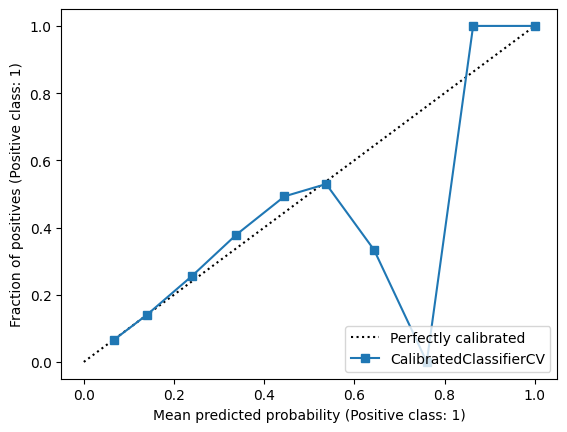

In [122]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    calibrated_xgb,
    X_test,
    y_test,
    n_bins=10
)

## 17. Additional Model Comparison: Random Forest

Compare calibrated Random Forest performance against Logistic Regression and XGBoost.

In [124]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf_pipe.fit(X_train, y_train);

In [125]:
from sklearn.calibration import CalibratedClassifierCV

rf_calibrated = CalibratedClassifierCV(rf_pipe, method="isotonic", cv=3)
rf_calibrated.fit(X_train, y_train)

rf_probs_cal = rf_calibrated.predict_proba(X_test)[:,1]

In [126]:
rf_roc_cal = roc_auc_score(y_test, rf_probs_cal)
rf_pr_cal = average_precision_score(y_test, rf_probs_cal)

print("Calibrated Random Forest ROC-AUC:", rf_roc_cal)
print("Calibrated Random Forest PR-AUC :", rf_pr_cal)
print("Mean predicted probability      :", rf_probs_cal.mean())
print("Observed positive rate          :", y_test.mean())

Calibrated Random Forest ROC-AUC: 0.6631213540778453
Calibrated Random Forest PR-AUC : 0.20720473171531548
Mean predicted probability      : 0.11131714422113292
Observed positive rate          : 0.11226694808784361


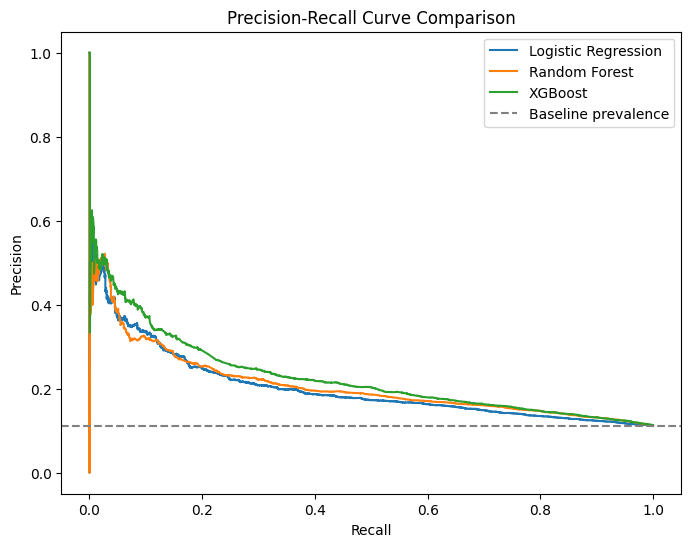

In [127]:
lr_probs = proba
rf_probs = rf_probs_cal
xgb_probs = probs

p_lr, r_lr, _ = precision_recall_curve(y_test, lr_probs)
p_rf, r_rf, _ = precision_recall_curve(y_test, rf_probs)
p_xgb, r_xgb, _ = precision_recall_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))

plt.plot(r_lr, p_lr, label="Logistic Regression")
plt.plot(r_rf, p_rf, label="Random Forest")
plt.plot(r_xgb, p_xgb, label="XGBoost")
plt.axhline(y=y_test.mean(), linestyle="--", color="gray", label="Baseline prevalence")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()

## 18. Uncertainty and Risk Segmentation

Bootstrap confidence intervals and summarize patients by risk tier and top-decile capture.

In [128]:
n_bootstraps = 1000
rng = np.random.default_rng(42)

scores = []

for _ in range(n_bootstraps):
    idx = rng.choice(len(y_test), size=len(y_test), replace=True)

    if len(np.unique(y_test.iloc[idx])) < 2:
        continue

    score = roc_auc_score(y_test.iloc[idx], probs[idx])
    scores.append(score)

ci_lower = np.percentile(scores, 2.5)
ci_upper = np.percentile(scores, 97.5)

print("ROC-AUC:", roc_auc_score(y_test, probs))
print("95% CI:", (ci_lower, ci_upper))

ROC-AUC: 0.6760618199906192
95% CI: (np.float64(0.6649525264044752), np.float64(0.6882090074199457))


In [129]:
risk_bins = [0, 0.1, 0.2, 1]
labels = ["Low", "Moderate", "High"]

X_test["risk_tier"] = pd.cut(probs, bins=risk_bins, labels=labels)

X_test["risk_tier"].value_counts(normalize=True)

,proportion
risk_tier,
Low,0.522014
Moderate,0.403900
High,0.074085


In [130]:
df_eval = pd.DataFrame({
    "risk": probs,
    "readmit": y_test
})

df_eval = df_eval.sort_values("risk", ascending=False)

top_10 = int(len(df_eval) * 0.1)

capture_rate = df_eval.iloc[:top_10]["readmit"].sum() / df_eval["readmit"].sum()

print("Top 10% risk captures:", capture_rate)

Top 10% risk captures: 0.23455684870188004


## 19. Artifact Export for Deployment

The trained model and a one-row patient template can be exported for the Streamlit app.  
These export cells are kept at the end of the notebook so the core analysis remains clean.


In [ ]:
joblib.dump(calibrated_xgb, "/content/drive/MyDrive/Projects/Diabetes/calibrated_xgb.pkl")

In [ ]:
patient_template = X_train.iloc[[0]].copy()
joblib.dump(patient_template, "/content/drive/MyDrive/Projects/Diabetes/patient_template.pkl")